# Photo: CLASS + EE2, CLASS + HMcode2020, and SYREN-NEW

Adapted from `Photo_CLASS_HMcode2020_vs_SYREN_NEW_minimal_matched.ipynb`. Compare matched nonlinear total-matter spectra, photometric angular-spectrum derivatives and GCph+WL Fisher constraints for all three models. The upstream `symbolic_pofk/examples/syren_new_example.ipynb` compares SYREN-NEW against CLASS × EE2 at the power-spectrum level; good agreement there motivates this test, but does not guarantee equally close Fisher matrices.

Run top to bottom with the kernel for this checkout. Fisher cells generate files under `results/`. **Saved outputs below are from the earlier two-model run and are stale until the notebook is rerun.**

In [1]:
from pathlib import Path
import os

os.environ.setdefault('OMP_NUM_THREADS', '8')
import matplotlib.pyplot as plt
import numpy as np
import cosmicfishpie
from cosmicfishpie.configs.context import build_analysis_context
from cosmicfishpie.cosmology.cosmology import cosmo_functions
from cosmicfishpie.fishermatrix.cosmicfish import FisherMatrix
from cosmicfishpie.analysis import fisher_matrix as fisher_analysis
from cosmicfishpie.analysis import fishconsumer, plot_comparison

repo_root = Path.cwd().resolve()
if not (repo_root / 'cosmicfishpie').is_dir():
    repo_root = repo_root.parent
package_root = Path(cosmicfishpie.__file__).resolve().parents[1]
if package_root != repo_root:
    raise RuntimeError(f'Kernel imports {package_root}, but notebook belongs to {repo_root}')
profiles = {
    'CLASS + EE2': ('class', 'class_config_yaml', repo_root / 'cosmicfishpie/configs/default_boltzmann_yaml_files/class/ee2_boost_photo.yaml'),
    'CLASS + HMcode2020': ('class', 'class_config_yaml', repo_root / 'cosmicfishpie/configs/default_boltzmann_yaml_files/class/hmcode2020_photo.yaml'),
    'SYREN-NEW': ('symbolic', 'symbolic_config_yaml', repo_root / 'cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/syren_new_photo.yaml'),
}
MODEL_COLORS = {'CLASS + EE2': '#0072B2', 'CLASS + HMcode2020': '#009E73', 'SYREN-NEW': '#D55E00'}
MODEL_STYLES = {'CLASS + EE2': '-', 'CLASS + HMcode2020': '-.', 'SYREN-NEW': '--'}
for label, (_, _, path) in profiles.items():
    assert path.is_file(), path
    print(label, path)
results_dir = repo_root / 'results/photo_class_ee2_vs_syren_new_minimal_matched'
results_dir.mkdir(parents=True, exist_ok=True)

CLASS + EE2 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/cosmicfishpie/configs/default_boltzmann_yaml_files/class/ee2_boost_photo.yaml
CLASS + HMcode2020 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/cosmicfishpie/configs/default_boltzmann_yaml_files/class/hmcode2020_photo.yaml
SYREN-NEW /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/syren_new_photo.yaml


## Matched inputs and comparison domain

The three profiles use the matched three-degenerate neutrino convention: `m_ncdm=mnu/3` three times, `N_ur=0.00641`, and `Omega_cdm=Omegam-Omegab-mnu/(93.14 h²)`. `10^9As` converts to CLASS `A_s` once. Do not pass `Neff` as a varying parameter. CLASS + EE2 multiplies the CLASS linear spectrum by the EE2 boost, CLASS + HMcode2020 uses native CLASS nonlinear corrections, and SYREN-NEW uses its own nonlinear prediction. For photometric cb requests, CLASS+EE2 applies its **total-matter boost to cb as an approximation**.

The direct diagnostic uses k=0.01–3 h/Mpc at z=0, 1, 2, within the matched symbolic profile and EE2 k range. `Pmm` accepts k in 1/Mpc and returns Mpc³; plots convert back to h/Mpc and (Mpc/h)³. The Fisher run holds mnu fixed at 0.06 eV while varying the five shared LCDM parameters (and survey nuisances).

In [2]:
FIDUCIAL_LCDM = {'10^9As': 2.1, 'Omegam': 0.32, 'Omegab': 0.05, 'h': 0.67, 'ns': 0.96, 'mnu': 0.06}
FIDUCIAL_W0WA = {**FIDUCIAL_LCDM, 'w0': -1.0, 'wa': 0.0}
LCDM_FREEPARS = {name: 0.01 for name in FIDUCIAL_LCDM if name != 'mnu'}
W0WA_FREEPARS = {**LCDM_FREEPARS, 'w0': 0.01, 'wa': 0.05}
K_HMPC = np.logspace(-2, np.log10(3.0), 200)
REDSHIFTS = (0.0, 1.0, 2.0)
print('LCDM Fisher parameters:', LCDM_FREEPARS)

LCDM Fisher parameters: {'10^9As': 0.01, 'Omegam': 0.01, 'Omegab': 0.01, 'h': 0.01, 'ns': 0.01}


## Direct total-matter spectra

Compare linear spectra first to isolate background/amplitude differences; then compare the nonlinear result. Residuals for HMcode2020 and SYREN-NEW are both relative to CLASS + EE2. The reported maxima are descriptive, not pass/fail thresholds.

In [3]:
def make_cosmology(label, fiducial, cosmo_model='LCDM'):
    code, yaml_key, yaml_path = profiles[label]
    context = build_analysis_context(
        options={
            'code': code, yaml_key: str(yaml_path), 'cosmo_model': cosmo_model,
            'nonlinear': True, 'feedback': 0,
            'specs_dir': str(repo_root / 'cosmicfishpie/configs/default_survey_specifications') + '/',
        },
        observables=['GCph', 'WL'], freepars={}, fiducialpars=fiducial,
        survey_name='Euclid', cosmo_model=cosmo_model,
    )
    return cosmo_functions(fiducial, configuration=context)

def power_hunits(cosmology, fiducial, z, nonlinear):
    h = fiducial['h']
    return np.asarray(cosmology.Pmm(z, K_HMPC * h, nonlinear=nonlinear)) * h**3

def compare_spectra(fiducial, cosmo_model='LCDM'):
    cosmologies = {label: make_cosmology(label, fiducial, cosmo_model) for label in profiles}
    referencelab = 'CLASS + HMcode2020'
    rows = []
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col')
    for column, nonlinear in enumerate((False, True)):
        for z in REDSHIFTS:
            reference = power_hunits(cosmologies[referencelab], fiducial, z, nonlinear)
            for label, cosmology in cosmologies.items():
                power = power_hunits(cosmology, fiducial, z, nonlinear)
                axes[0, column].loglog(K_HMPC, power, MODEL_STYLES[label], color=MODEL_COLORS[label], alpha=1 - 0.2 * z, label=f'{label} z={z:g}')
                if label != referencelab:
                    residual = 100 * (power / reference - 1)
                    axes[1, column].semilogx(K_HMPC, residual, MODEL_STYLES[label], color=MODEL_COLORS[label], alpha=1 - 0.2 * z, label=f'{label} z={z:g}')
                    rows.append((('nonlinear' if nonlinear else 'linear'), label, z, float(np.max(np.abs(residual)))))
        axes[0, column].set_title('Nonlinear' if nonlinear else 'Linear')
        axes[0, column].set_ylabel('P(k) [(Mpc/h)³]')
        axes[1, column].axhline(0, color='k', lw=0.7)
        axes[1, column].axhline(3, color='grey', ls=':', lw=0.7)
        axes[1, column].axhline(-3, color='grey', ls=':', lw=0.7)
        axes[1, column].set(xlabel='k [h/Mpc]', ylabel=f'(model / {referencelab}) − 1 [%]')
        axes[0, column].legend(fontsize=8)
        axes[1, column].legend(fontsize=8)
        axes[1, 0].set_ylim(-1,1)
    fig.suptitle(f'{cosmo_model}: total-matter spectra')
    fig.tight_layout()
    plt.show()
    return rows

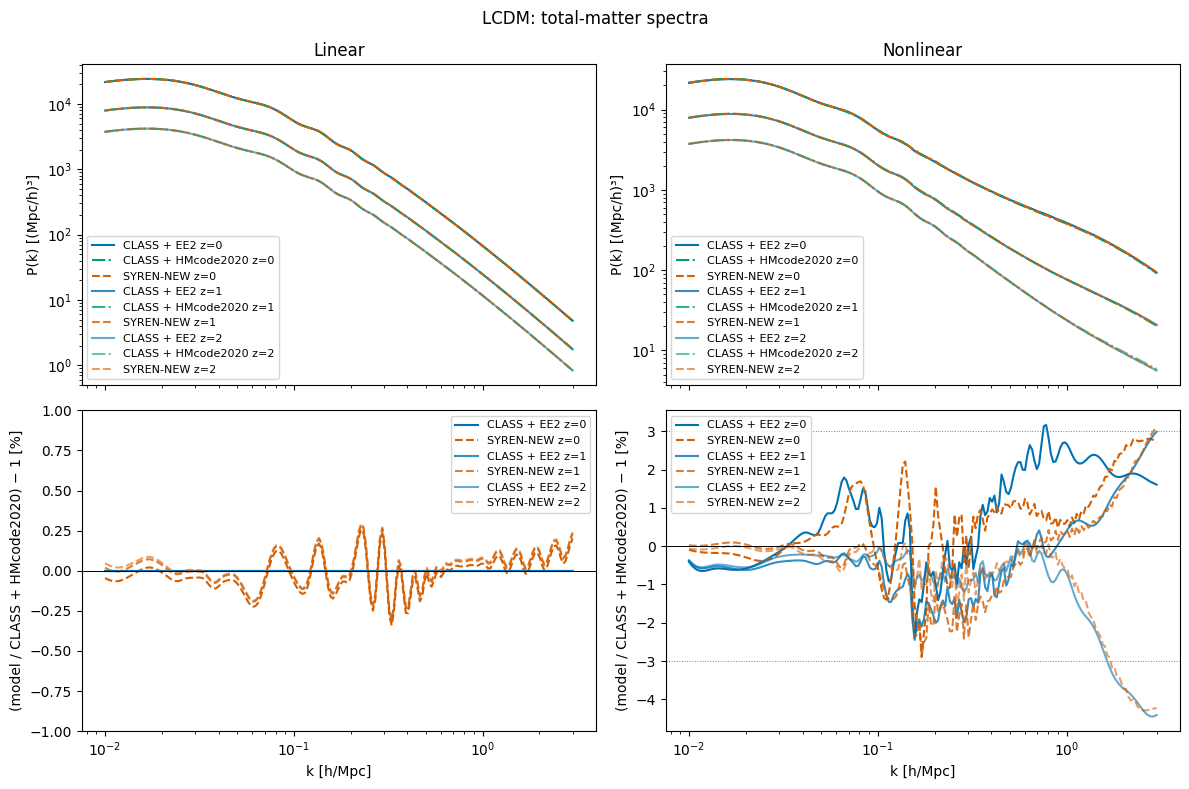

model, z, max |SYREN / CLASS − 1| [%]
('linear', 'CLASS + EE2', 0.0, 0.0)
('linear', 'SYREN-NEW', 0.0, 0.34135587429126035)
('linear', 'CLASS + EE2', 1.0, 0.0)
('linear', 'SYREN-NEW', 1.0, 0.31152228021547046)
('linear', 'CLASS + EE2', 2.0, 0.0)
('linear', 'SYREN-NEW', 2.0, 0.30379177465615914)
('nonlinear', 'CLASS + EE2', 0.0, 3.1657000347288022)
('nonlinear', 'SYREN-NEW', 0.0, 2.896129775141598)
('nonlinear', 'CLASS + EE2', 1.0, 2.991238114882644)
('nonlinear', 'SYREN-NEW', 1.0, 3.0872644558808338)
('nonlinear', 'CLASS + EE2', 2.0, 4.4499793641812335)
('nonlinear', 'SYREN-NEW', 2.0, 4.290783886624827)


In [4]:
spectrum_summary = compare_spectra(FIDUCIAL_LCDM)
print('model, z, max |SYREN / CLASS − 1| [%]')
for row in spectrum_summary:
    print(row)

## GCph + WL Fisher runs

All three runs use identical survey settings, fiducials, finite-difference steps and photometric observables. These cells compute the full photo Fisher matrices and write them to the dedicated results directory. `calculation.derivs_dict` provides the derivatives for every Fisher probe; photometric entries are angular-spectrum dictionaries keyed by parameter and channel (and `photo_derivs` remains an alias).

In [5]:
def run_photo_comparison(cosmo_model, fiducial, freepars):
    common = {
        'accuracy': 1, 'derivatives': '3PT', 'feedback': 0,
        'nonlinear': True, 'survey_name': 'Euclid',
        'survey_name_photo': 'Euclid-Photometric-ISTF-Pessimistic',
        'specs_dir': str(repo_root / 'cosmicfishpie/configs/default_survey_specifications') + '/',
        'cosmo_model': cosmo_model, 'results_dir': str(results_dir) + '/',
    }
    runs = {}
    profile_suffixes = {'CLASS + EE2': 'class_ee2', 'CLASS + HMcode2020': 'class_hmcode2020', 'SYREN-NEW': 'symbolic_syren_new'}
    for label, (code, yaml_key, yaml_path) in profiles.items():
        outroot = f'{cosmo_model}_photo_{profile_suffixes[label]}'
        options = {**common, 'code': code, yaml_key: str(yaml_path), 'outroot': outroot}
        calculation = FisherMatrix(
            fiducialpars=dict(fiducial), freepars=dict(freepars), options=options,
            observables=['GCph', 'WL'], cosmoModel=cosmo_model, surveyName='Euclid',
        )
        fisher = calculation.compute()
        runs[label] = {
            'file_name': Path(fisher.file_name),
            'derivatives': calculation.derivs_dict,
            'cls': calculation.photo_LSS.cls,
        }
        print(label, runs[label]['file_name'])
    return runs

In [6]:
lcdm_runs = run_photo_comparison('LCDM', FIDUCIAL_LCDM, LCDM_FREEPARS)


  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_LCDM_photo_class_ee2_GCphWL_FM.txt

CLASS + EE2 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/CosmicFish_v1.3.1_LCDM_photo_class_ee2_GCphWL_FM.txt

  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_LCDM_photo_class_hmcode2020_GCphWL_FM.txt

CLASS + HMcode2020 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/CosmicFish_v1.3.1_LCDM_photo_class_hmcode2020_GCphWL_FM.txt

  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_LCDM_photo_symbolic_syren_new_GCph

## Photometric derivative diagnostic

Compare one auto-spectrum channel across the three photo derivative dictionaries. Inspect several channels (for example `WL 1xWL 1` or `GCph 1xGCph 1`) if constraints differ. Fractional residuals use CLASS + EE2 as denominator; points close to a zero crossing are masked.

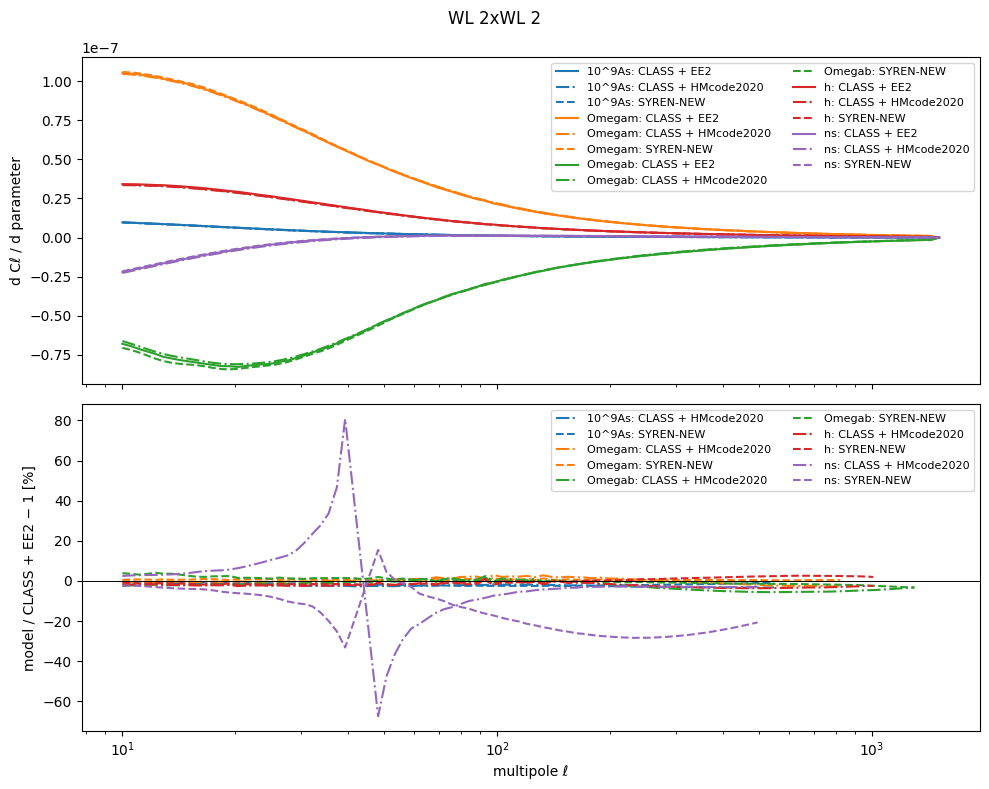

In [7]:
def plot_photo_derivatives(runs, parameters, channel='WL 2xWL 2'):
    reference = runs['CLASS + EE2']
    ell = np.asarray(reference['cls']['ells'])
    assert channel in reference['cls'], list(reference['cls'])[:10]
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    parameter_colors = plt.get_cmap('tab10').colors
    for color, parameter in zip(parameter_colors, parameters):
        class_deriv = np.asarray(reference['derivatives'][parameter][channel])
        for label, run in runs.items():
            derivative = np.asarray(run['derivatives'][parameter][channel])
            axes[0].semilogx(ell, derivative, MODEL_STYLES[label], color=color, label=f'{parameter}: {label}')
            if label == 'CLASS + EE2':
                continue
            mask = np.abs(class_deriv) > 0.02 * np.max(np.abs(class_deriv))
            axes[1].semilogx(ell[mask], 100 * (derivative[mask] / class_deriv[mask] - 1), MODEL_STYLES[label], color=color, label=f'{parameter}: {label}')
    axes[0].set_ylabel('d Cℓ / d parameter')
    axes[0].legend(ncol=2, fontsize=8)
    axes[1].axhline(0, color='k', lw=0.7)
    axes[1].set(xlabel='multipole ℓ', ylabel='model / CLASS + EE2 − 1 [%]')
    axes[1].legend(ncol=2, fontsize=8)
    fig.suptitle(channel)
    fig.tight_layout()
    plt.show()

plot_photo_derivatives(lcdm_runs, LCDM_FREEPARS)

## Marginal constraints and Fisher information

Use the exported Fisher matrices (including the same nuisance treatment for all three). The shaded `plot_comparison.ploterrs` plot shows relative marginalized (light) and unmarginalized (dark) 1σ errors against CLASS + EE2. The `fishconsumer` triangle plot shows marginalized cosmological constraints and degeneracies. A small P(k) residual does not guarantee a small Fisher residual: derivatives, kernels, nuisance degeneracies and matrix inversion enter the forecast.

('Fishers names: ', ['CLASS + EE2', 'CLASS + HMcode2020', 'SYREN-NEW'])
('parameters to plot: ', ['10^9As', 'Omegam', 'Omegab', 'h', 'ns'])
X tick labels ---> :   ['10^9As', '\\Omega_{{\\rm m}, 0}', '\\Omega_{{\\rm b}, 0}', 'h', 'n_{\\rm s}']


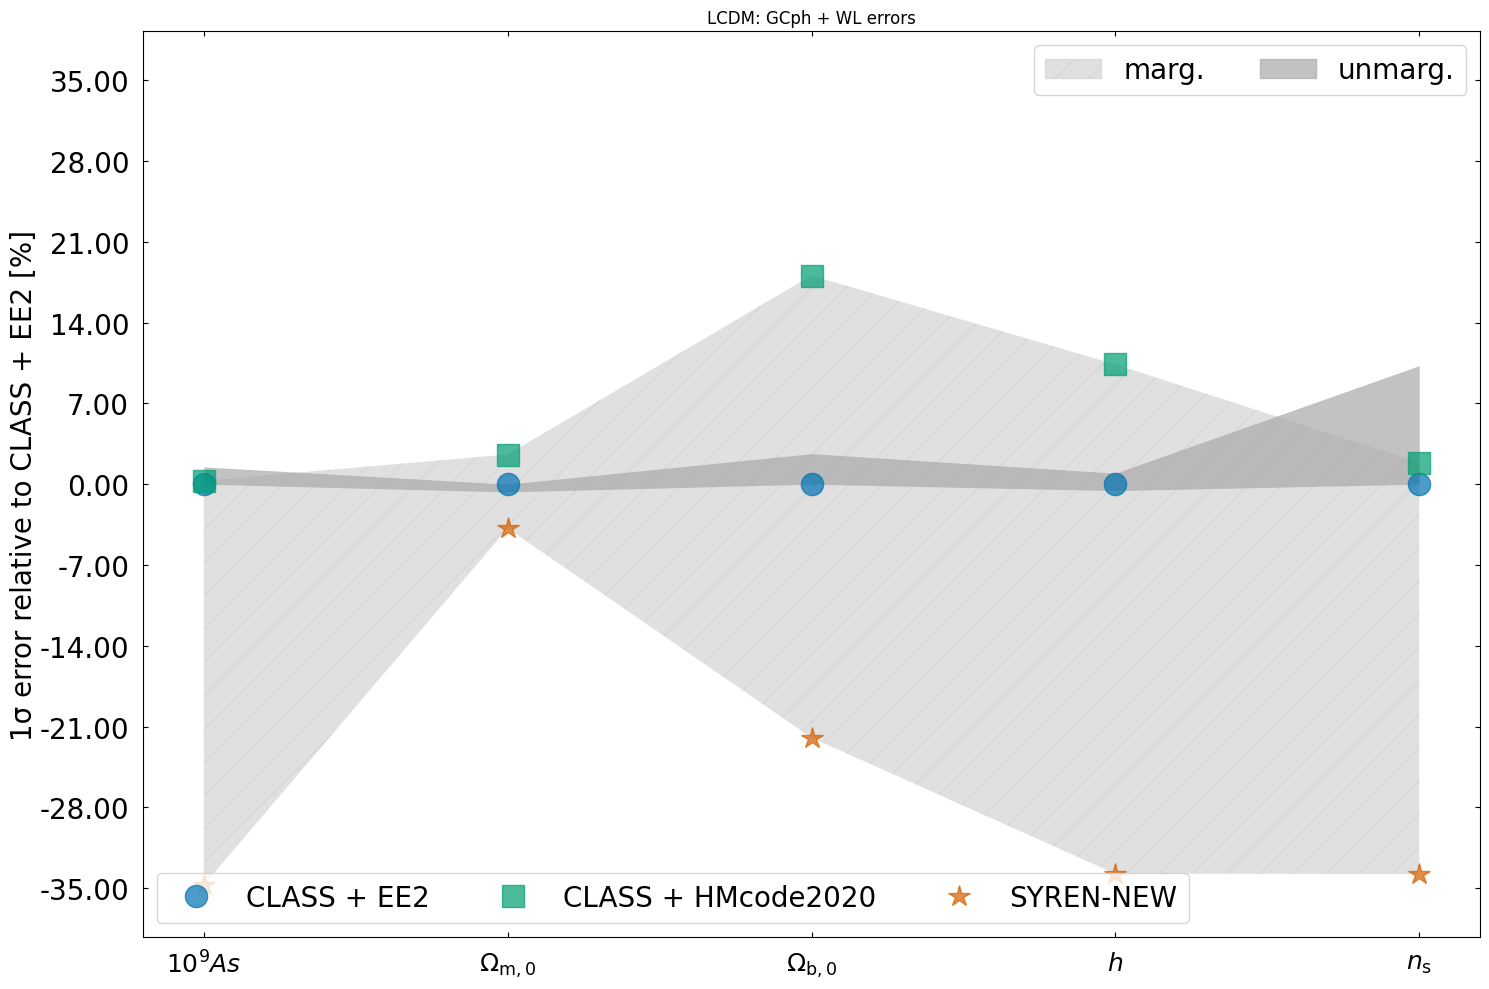

marginal error differences vs CLASS + EE2 [%]: {'CLASS + HMcode2020': {'10^9As': 0.30399962842744266, 'Omegam': 2.5709859959614167, 'Omegab': 18.077509637177734, 'h': 10.37495568961968, 'ns': 1.8766418193068235}, 'SYREN-NEW': {'10^9As': -34.72998171887735, 'Omegam': -3.8214656251875256, 'Omegab': -21.967778129505934, 'h': -33.75893227775023, 'ns': -33.77954224239165}}


In [11]:
def compare_constraints(runs, freepars, cosmo_model):
    labels = list(runs)
    matrices = [fisher_analysis.fisher_matrix(file_name=str(runs[label]['file_name'])) for label in labels]
    names = list(freepars)
    plot_comparison.ploterrs(
        matrices, labels, parstoplot=names, compare_to_index=0,
        marginalize_pars=True, plot_marg=True, plot_unmarg=True,
        colors=[MODEL_COLORS[label] for label in labels],
        y_label='1σ error relative to CLASS + EE2 [%]',
        figure_title=f'{cosmo_model}: GCph + WL errors',
        figsize=(15, 10), savefig=False,
    )
    plt.gcf().savefig(results_dir / f'{cosmo_model}_photo_relative_errors.pdf', bbox_inches='tight')
    plt.show()
    errors = {label: {name: matrices[i].get_confidence_bounds()[matrices[i].get_param_names().index(name)] for name in names} for i, label in enumerate(labels)}
    return {label: {name: 100 * (errors[label][name] / errors['CLASS + EE2'][name] - 1) for name in names} for label in labels if label != 'CLASS + EE2'}

print('marginal error differences vs CLASS + EE2 [%]:', compare_constraints(lcdm_runs, LCDM_FREEPARS, 'LCDM'))

## Fisher contours

Use `fishconsumer` to show all three Fisher forecasts around the same fiducial values. The displayed five-parameter subspace is marginalized over the survey nuisance parameters.

Plot saved to: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/LCDM_photo_fisher_contours.pdf


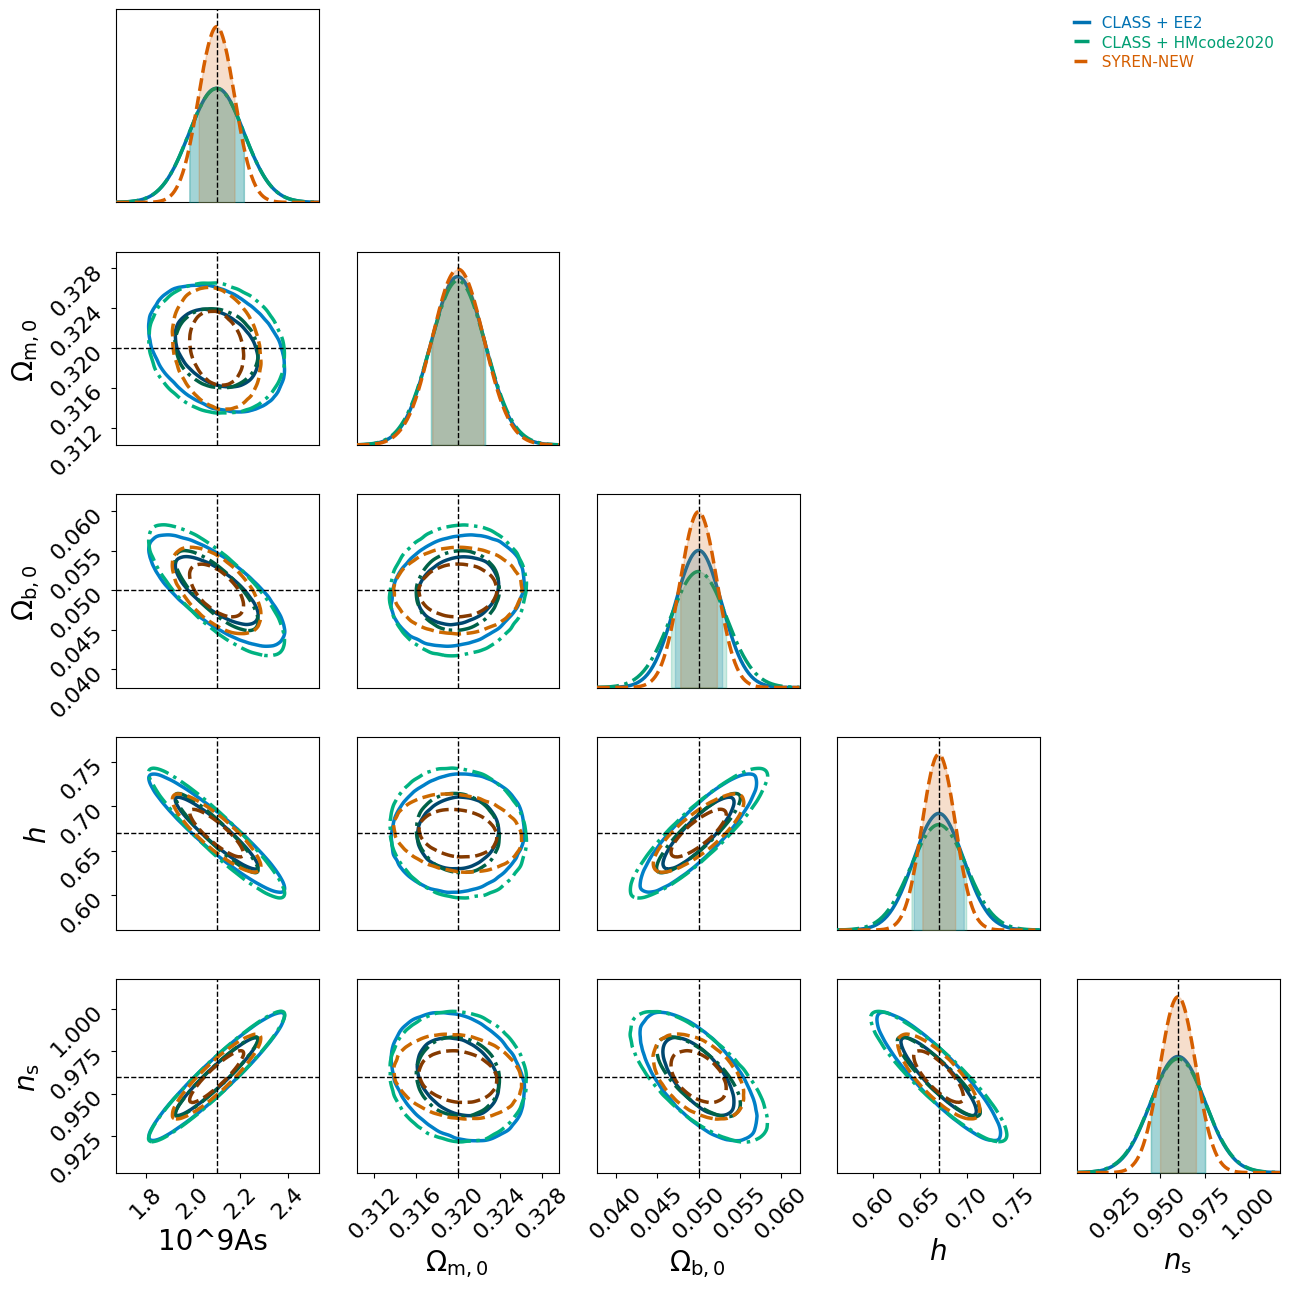

In [9]:
def plot_contours(runs, freepars, fiducial, cosmo_model):
    labels = list(runs)
    matrices = [fisher_analysis.fisher_matrix(file_name=str(runs[label]['file_name'])) for label in labels]
    fig = fishconsumer.make_triangle_plot(
        fishers=matrices, fisher_labels=labels, params=list(freepars),
        colors=[MODEL_COLORS[label] for label in labels],
        truth_values={name: fiducial[name] for name in freepars},
        shade_fisher=[False] * len(labels),
        ls_fisher=[MODEL_STYLES[label] for label in labels],
        legend_kwargs={'fontsize': 11, 'loc': 'upper right'},
        savefile=str(results_dir / f'{cosmo_model}_photo_fisher_contours.pdf'),
    )
    plt.show()
    return fig

lcdm_contours = plot_contours(lcdm_runs, LCDM_FREEPARS, FIDUCIAL_LCDM, 'LCDM')

## Optional w0waCDM comparison

Run these only after reviewing the LCDM results. All three profiles allow w0waCDM and use the same fiducial/steps. Interpreting unusually large Fisher differences should start with the linear and nonlinear spectra, then the photometric derivative panel.

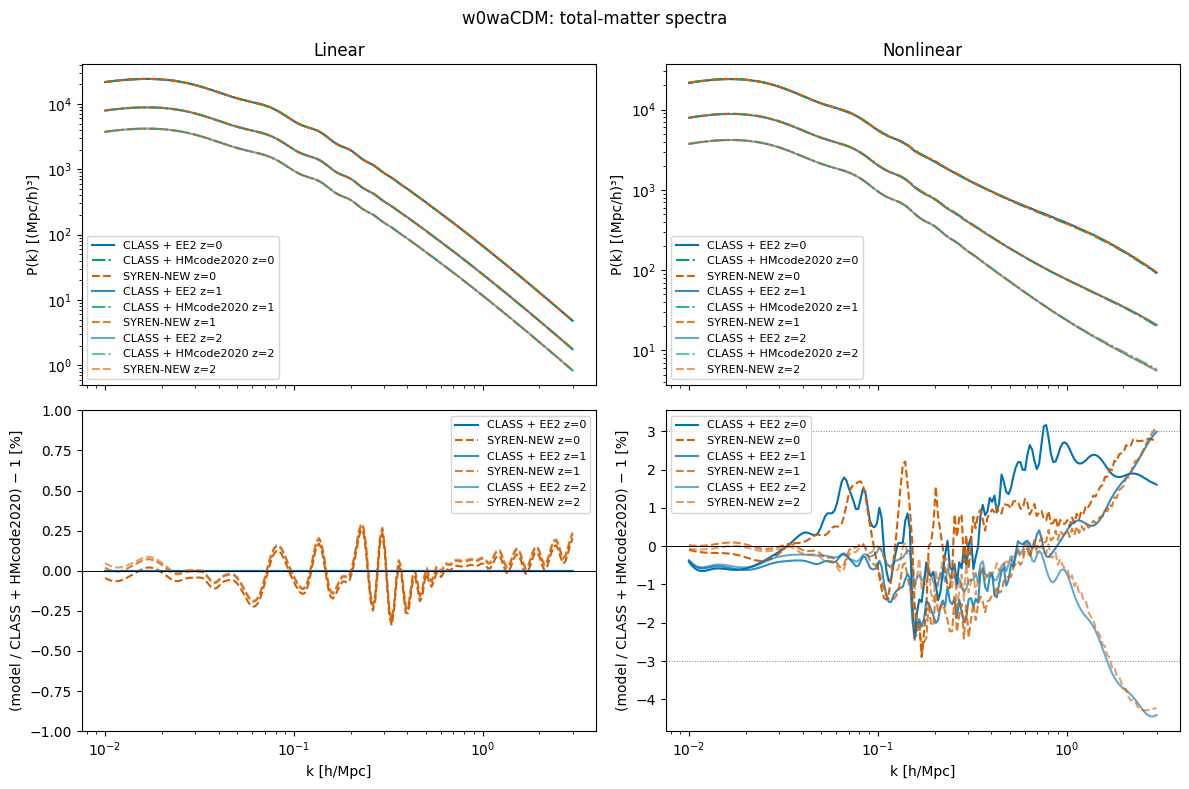


  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_w0waCDM_photo_class_ee2_GCphWL_FM.txt

CLASS + EE2 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/CosmicFish_v1.3.1_w0waCDM_photo_class_ee2_GCphWL_FM.txt

  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_w0waCDM_photo_class_hmcode2020_GCphWL_FM.txt

CLASS + HMcode2020 /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/CosmicFish_v1.3.1_w0waCDM_photo_class_hmcode2020_GCphWL_FM.txt

  Fisher matrix exported: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched//CosmicFish_v1.3.1_w0waCDM_photo_symbolic

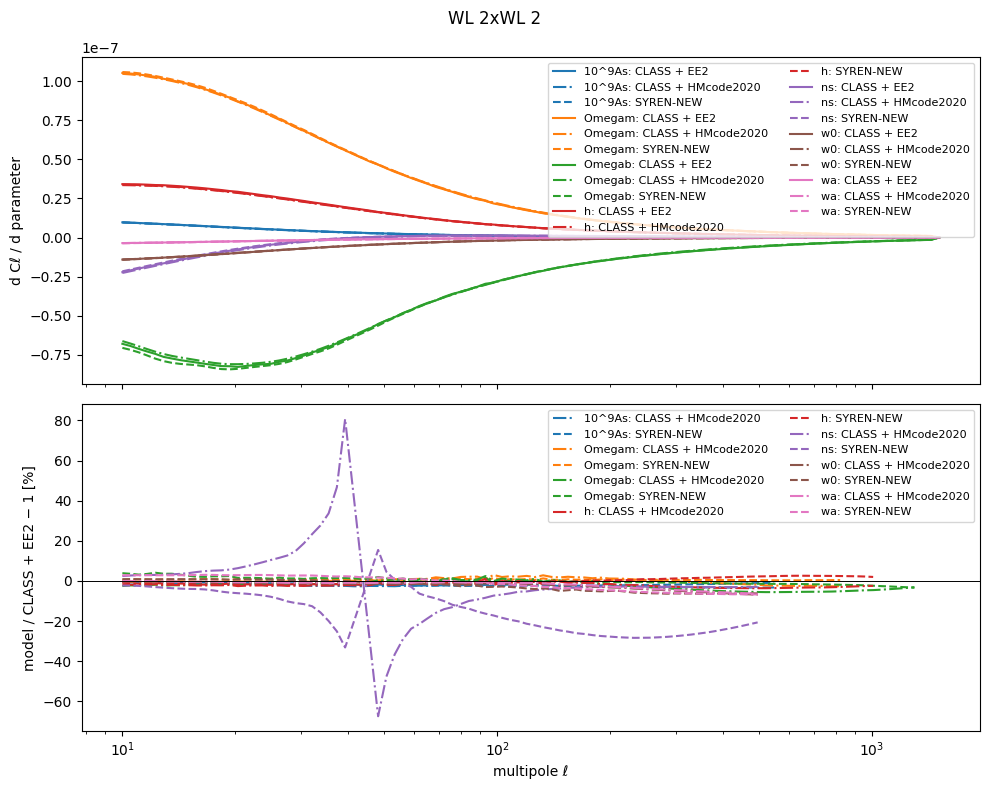

('Fishers names: ', ['CLASS + EE2', 'CLASS + HMcode2020', 'SYREN-NEW'])
('parameters to plot: ', ['10^9As', 'Omegam', 'Omegab', 'h', 'ns', 'w0', 'wa'])
X tick labels ---> :   ['10^9As', '\\Omega_{{\\rm m}, 0}', '\\Omega_{{\\rm b}, 0}', 'h', 'n_{\\rm s}', 'w_0', 'w_a']


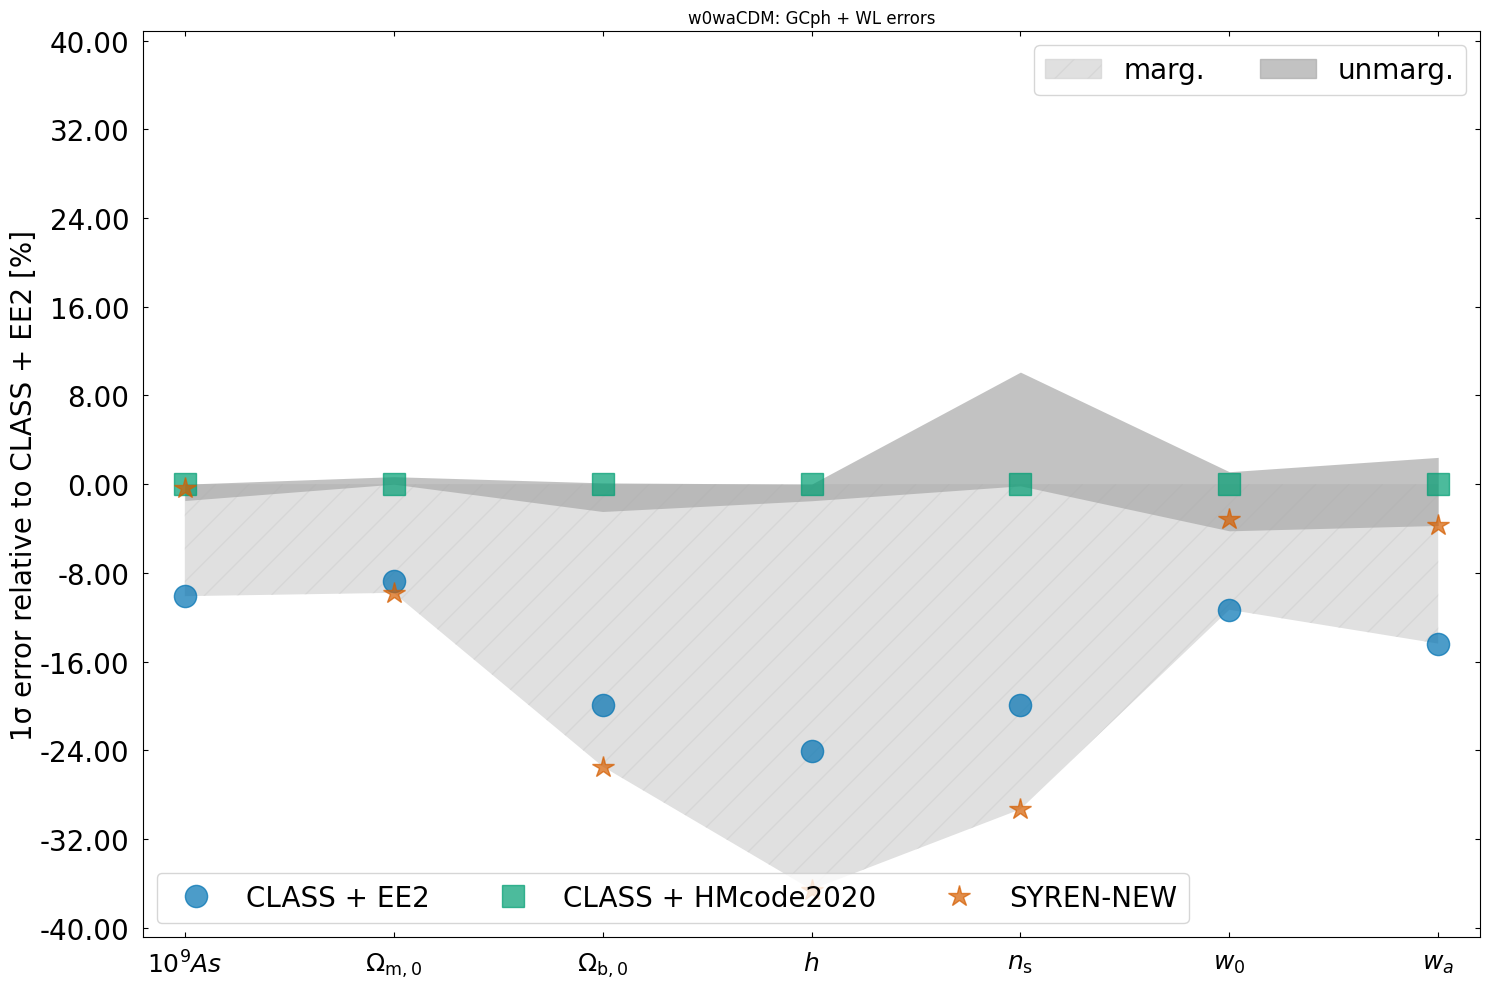

Plot saved to: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/photo_class_ee2_vs_syren_new_minimal_matched/w0waCDM_photo_fisher_contours.pdf


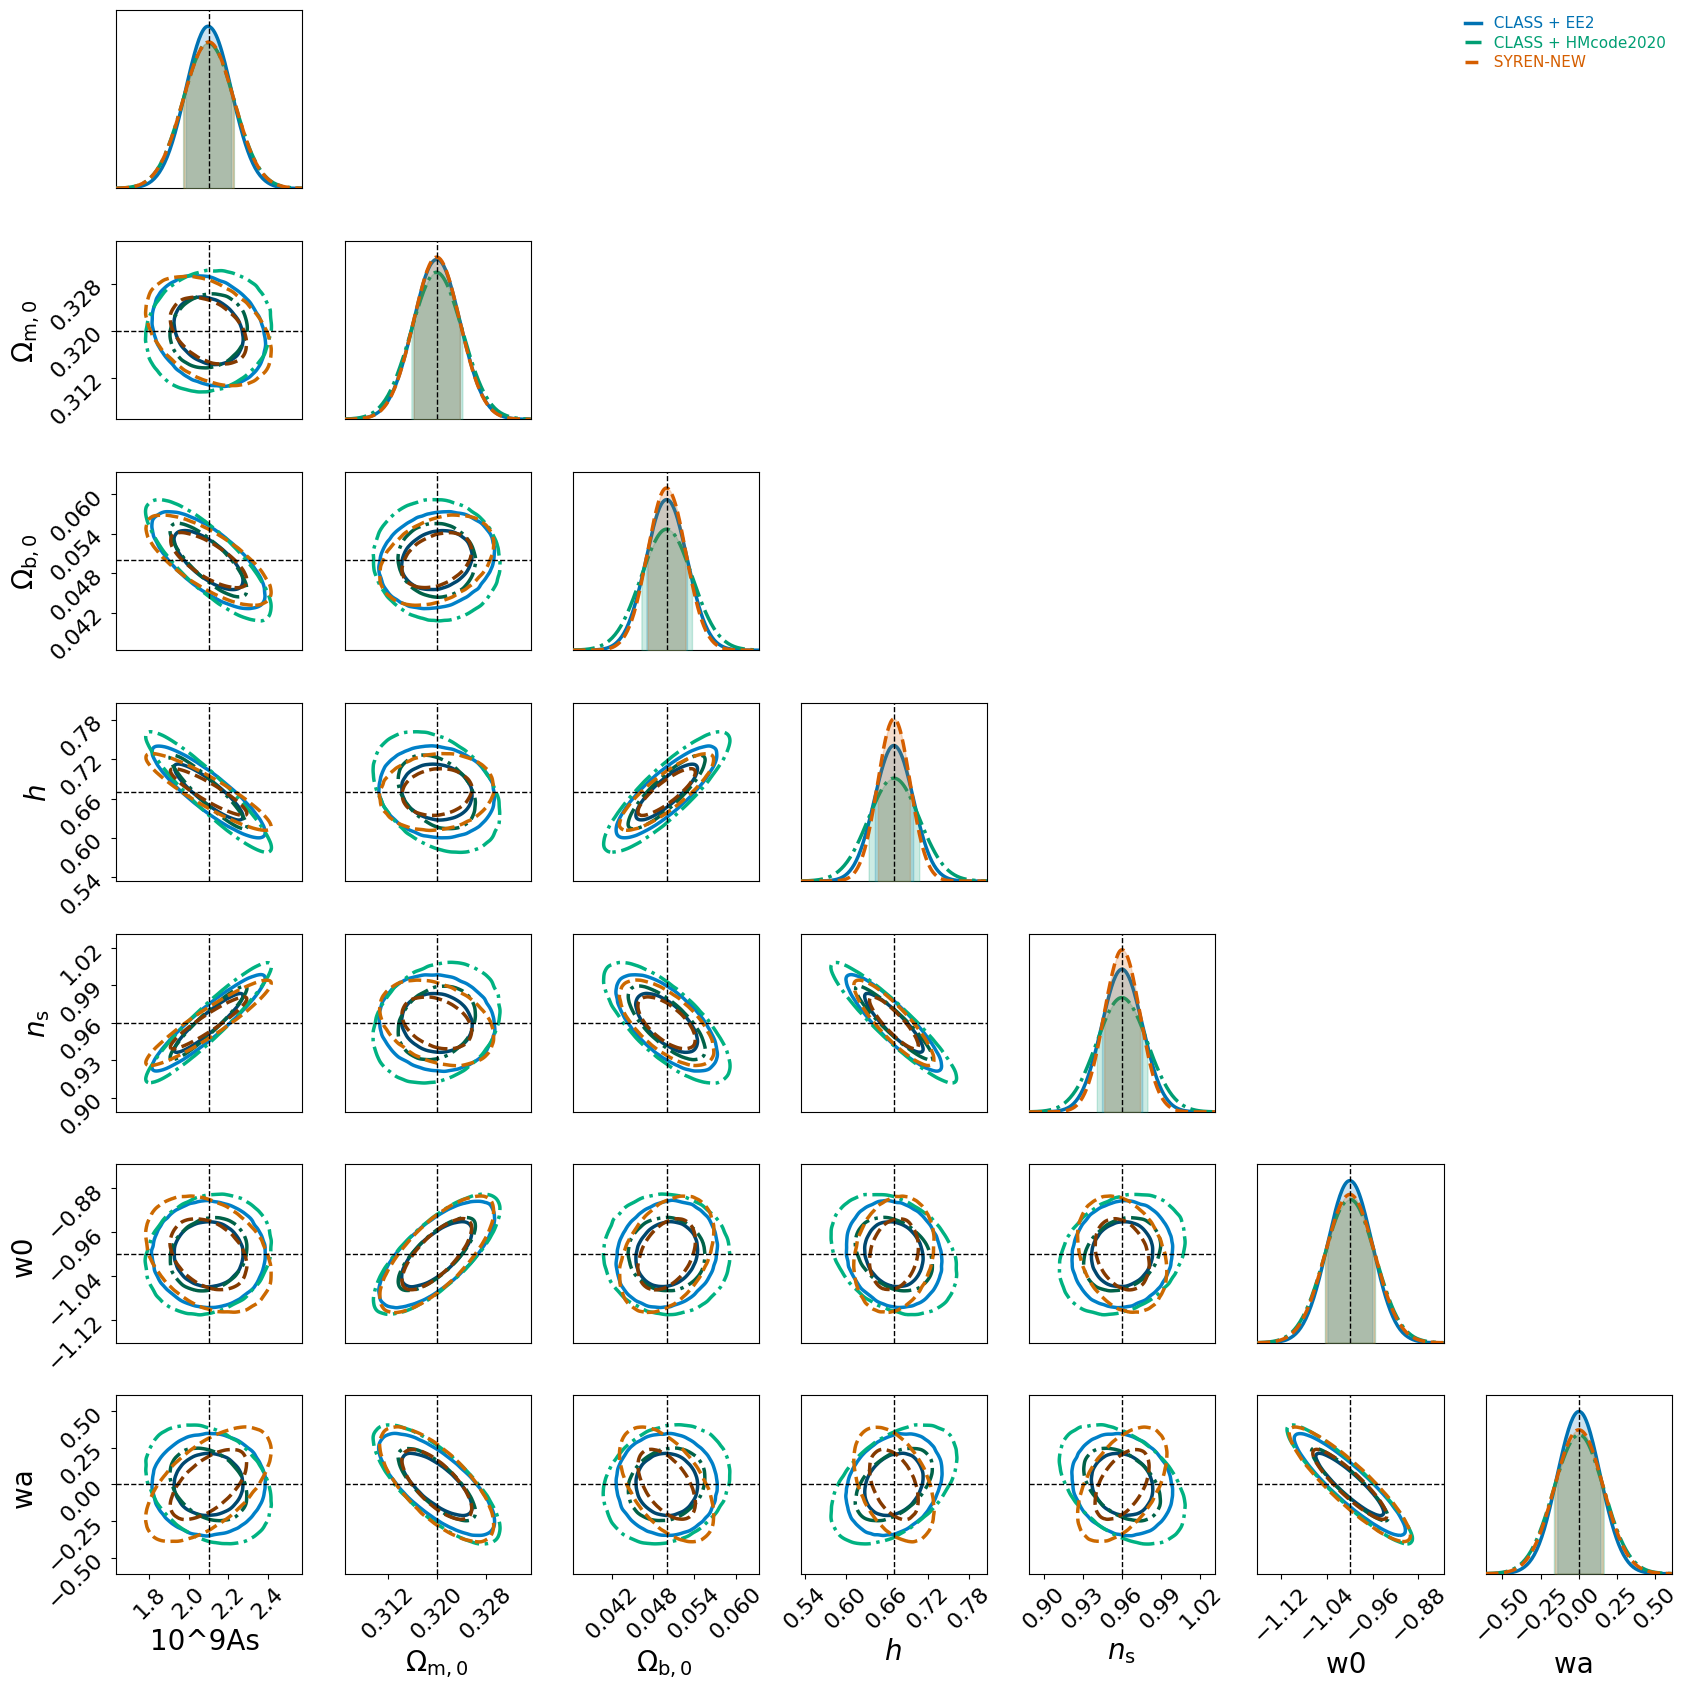

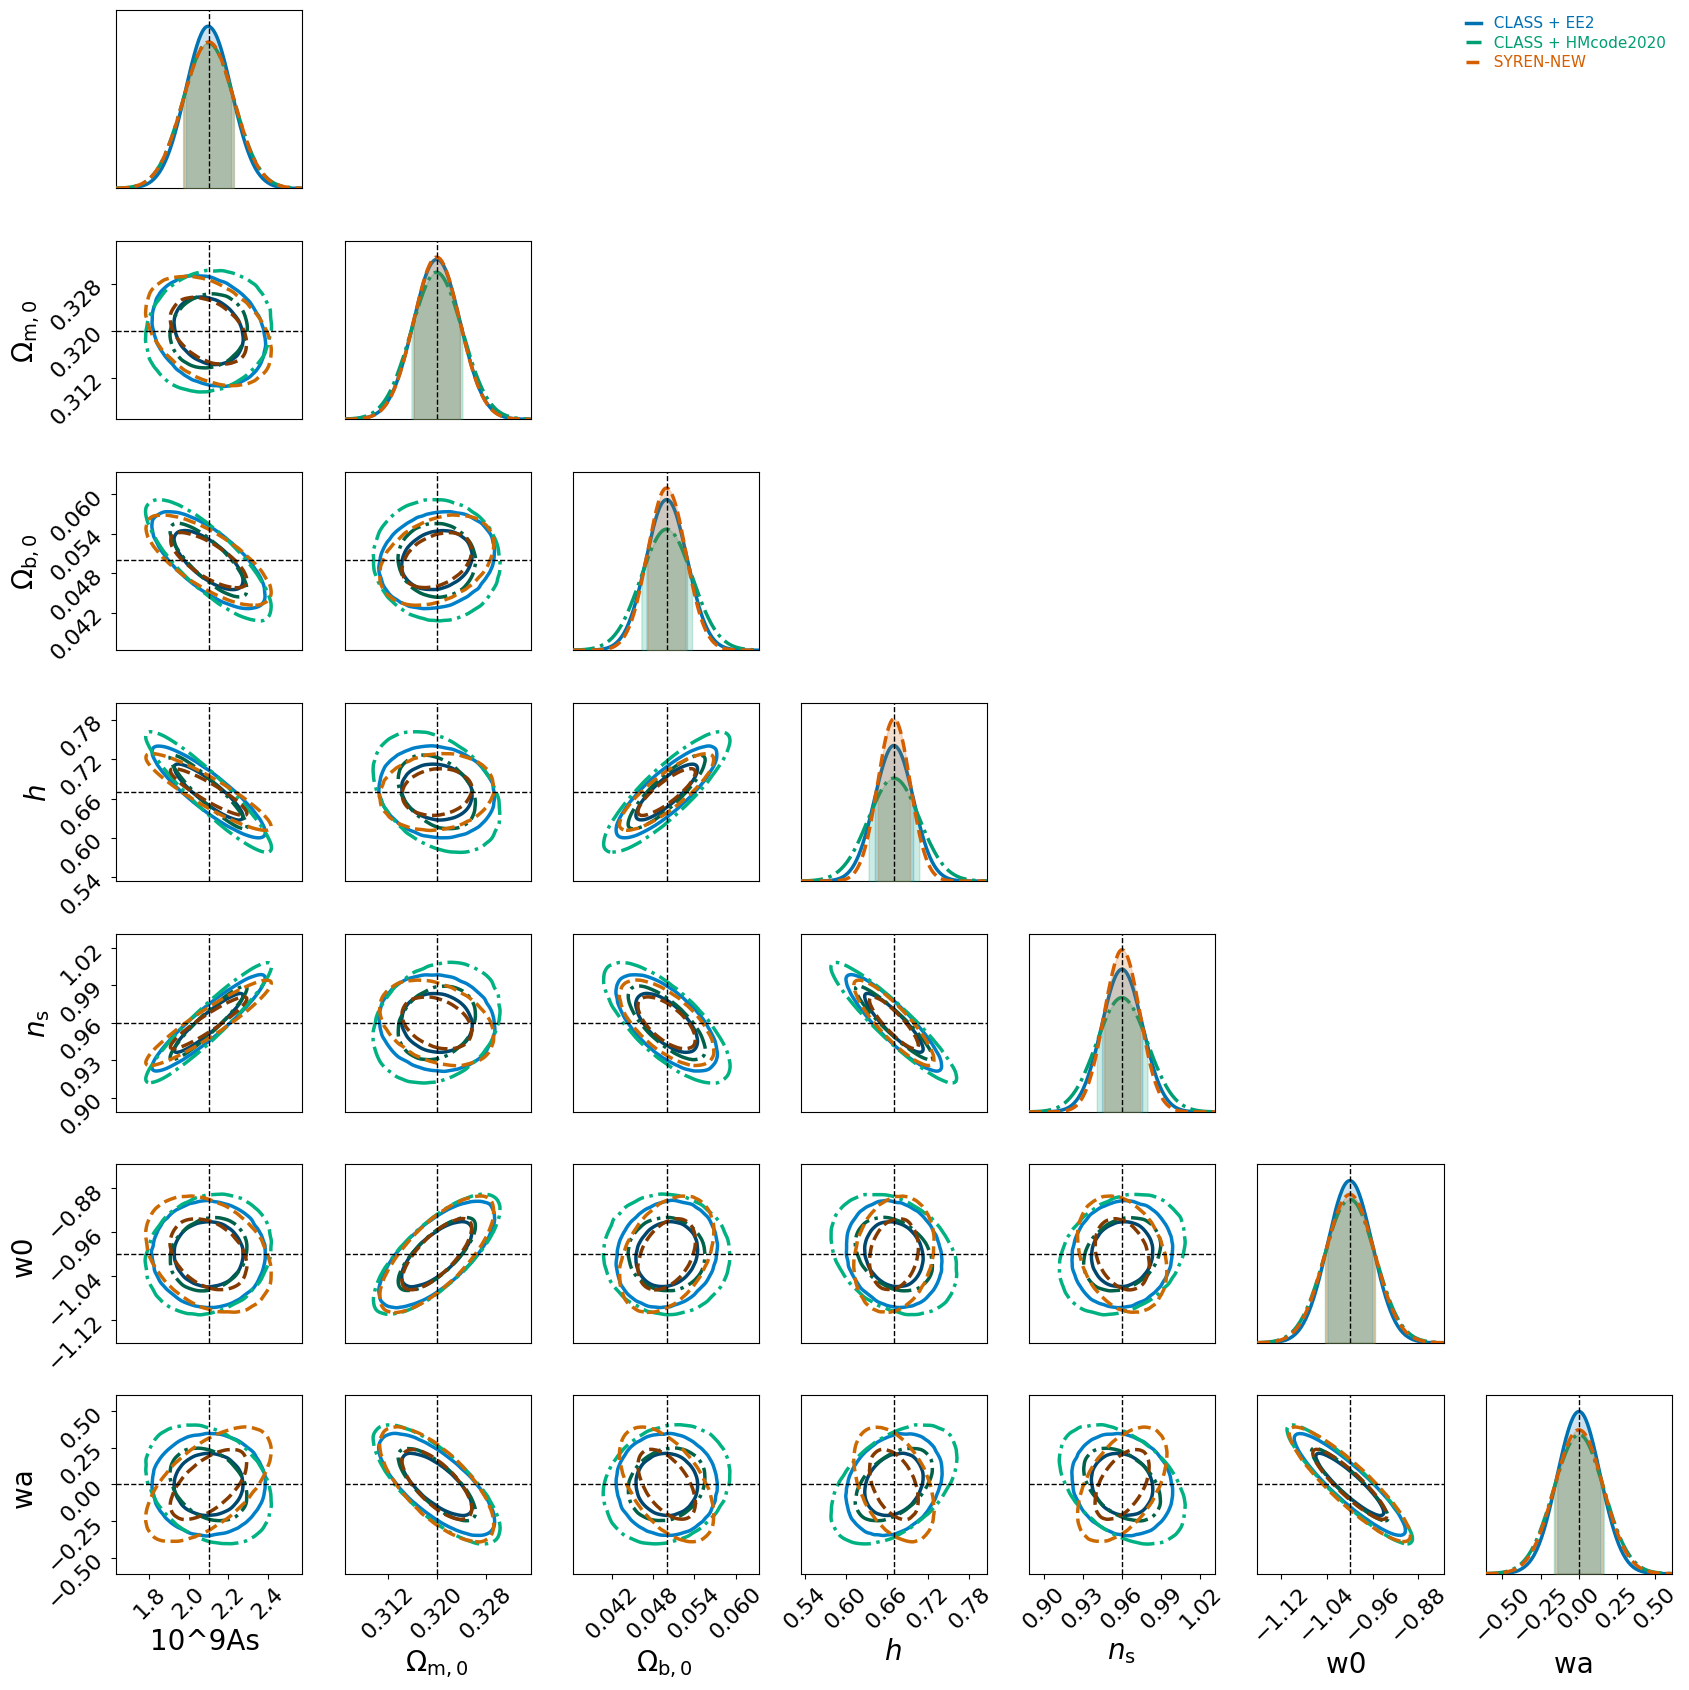

In [10]:
# Uncomment to extend the comparison.
compare_spectra(FIDUCIAL_W0WA, 'w0waCDM')
w0wa_runs = run_photo_comparison('w0waCDM', FIDUCIAL_W0WA, W0WA_FREEPARS)
plot_photo_derivatives(w0wa_runs, W0WA_FREEPARS)
compare_constraints(w0wa_runs, W0WA_FREEPARS, 'w0waCDM')
plot_contours(w0wa_runs, W0WA_FREEPARS, FIDUCIAL_W0WA, 'w0waCDM')